# Лабораторная работа №7 по ТМО
## Перфильев Виктор Анатольевич
## Группа ИБМ3-65Б

#### Цель работы. Изучение основных методов анализа и прогнозирование временных рядов.

## 1. Импорт библиотек и загрузка датасета

In [24]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import warnings
from gplearn.genetic import SymbolicRegressor
from gmdhpy.gmdh import MultilayerGMDH, RefFunctionType
from sklearn.metrics import mean_squared_error, mean_absolute_error


warnings.filterwarnings('ignore')

ts = pd.read_csv('/Users/admin/monthly_champagne_sales.csv', sep=',', header=0, index_col=0, parse_dates=True)

#### В датасете находятся ежемесячные продажи шампанского за период с января 1964 года по сентябрь 1972 года.

#### Датасет хорошо подходит  потому что:
#### - данные идут по месяцам;
#### - наблюдений 105, то есть охвачено больше 3 лет;
#### - в данных хорошо видна сезонность;
#### - продажи растут и падают не случайно, а повторяются по месяцам;

### Основные характеристики

In [2]:
display(ts.describe())

,Sales
count,105.000000
mean,4761.152381
std,2553.502601
min,1413.000000
25%,3113.000000
50%,4217.000000
75%,5221.000000
max,13916.000000


## 2. Визуализация временного ряда и его основных характеристик

### График временного ряда

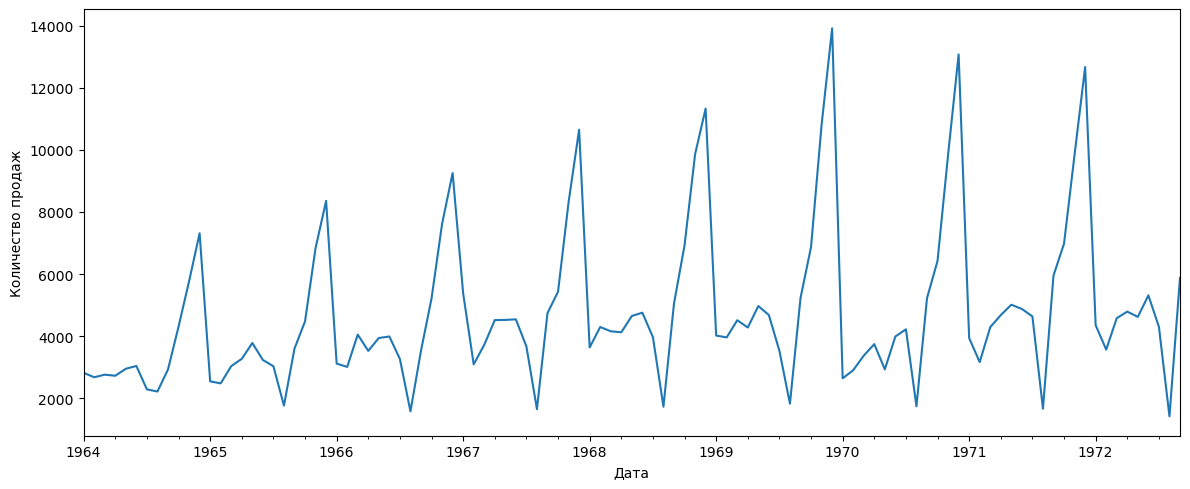

In [3]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(12, 5))
ts.plot(ax=ax, legend=False)
ax.set_ylabel('Количество продаж')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

### Первые 24 точки ряда

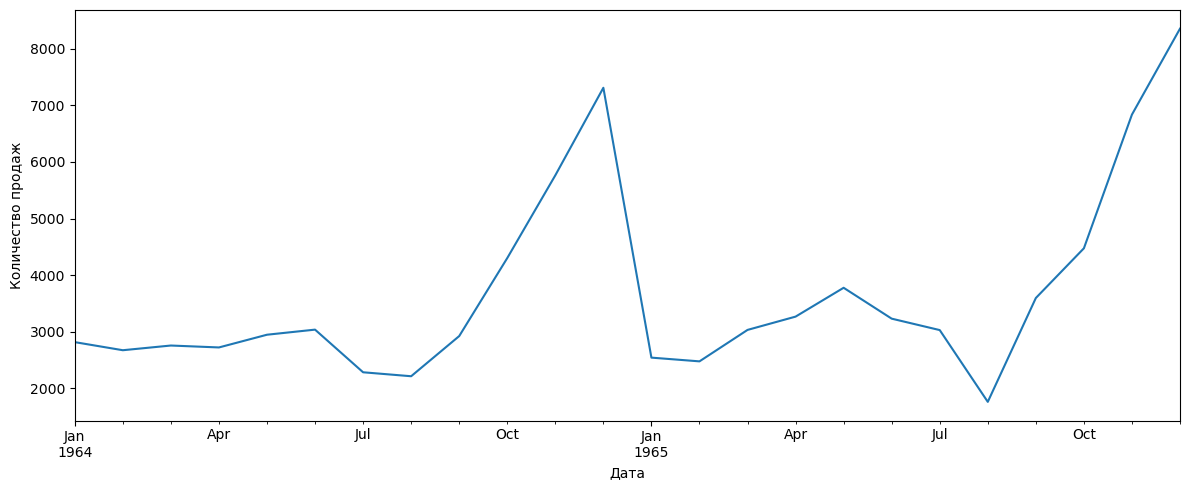

In [4]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(12, 5))
ts[:24].plot(ax=ax, legend=False)
ax.set_ylabel('Количество продаж')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

### Гистограмма распределения

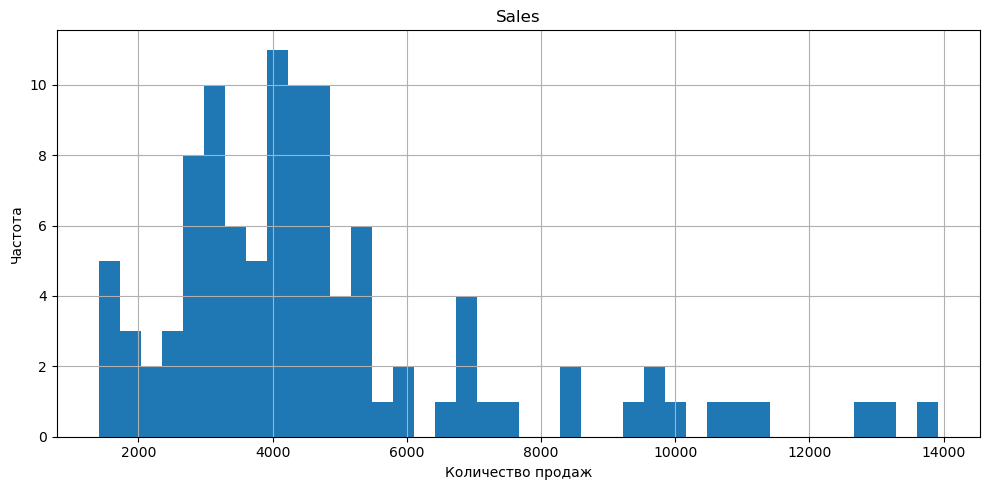

In [5]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10, 5))
ts.hist(ax=ax, legend=False, bins=40)
ax.set_xlabel('Количество продаж')
ax.set_ylabel('Частота')
pyplot.tight_layout()
pyplot.show()

### Оценка плотности распределения

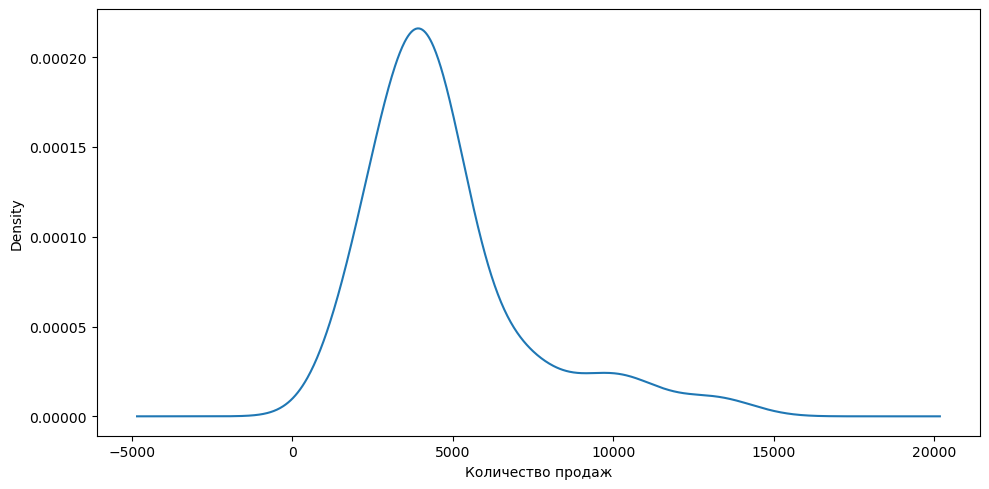

In [6]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10, 5))
ts.plot(ax=ax, kind='kde', legend=False)
ax.set_xlabel('Количество продаж')
pyplot.tight_layout()
pyplot.show()

### Автокорреляционная диаграмма

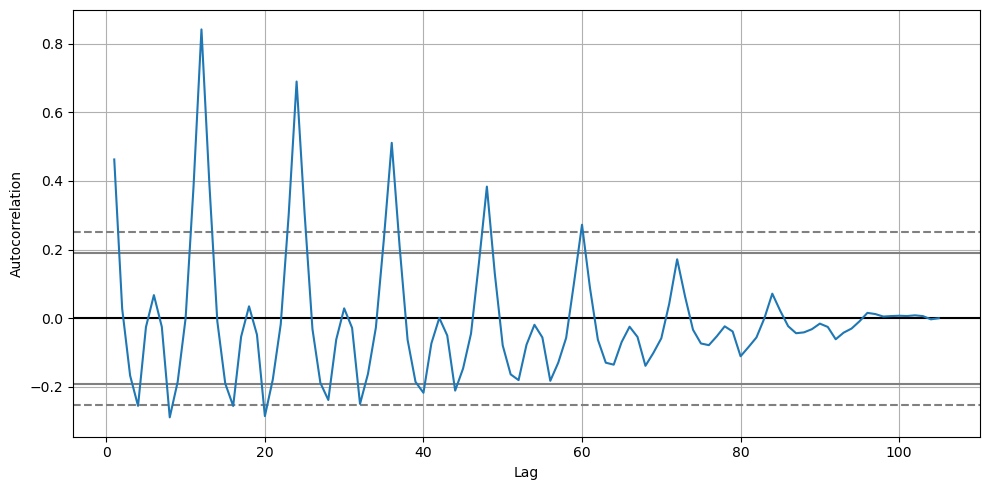

In [7]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10, 5))
pd.plotting.autocorrelation_plot(ts, ax=ax)
pyplot.tight_layout()
pyplot.show()

## 3. Разделение временного ряда на обучающую и тестовую выборки

In [8]:
#целочисленная метка шкалы времени 
xnum = list(range(ts.shape[0]))

#разделение выборки 
Y = ts.values.ravel()
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]

print(f'Общий размер ряда: {len(Y)} записей')
print(f'Обучающая выборка: {len(train)} записей (с {ts.index[0].strftime("%Y-%m-%d")} по {ts.index[train_size-1].strftime("%Y-%m-%d")})')
print(f'Тестовая выборка: {len(test)} записей (с {ts.index[train_size].strftime("%Y-%m-%d")} по {ts.index[-1].strftime("%Y-%m-%d")})')
print(f'Соотношение train/test: {len(train)/len(Y)*100:.1f}% / {len(test)/len(Y)*100:.1f}%')

Общий размер ряда: 105 записей
Обучающая выборка: 73 записей (с 1964-01-01 по 1970-01-01)
Тестовая выборка: 32 записей (с 1970-02-01 по 1972-09-01)
Соотношение train/test: 69.5% / 30.5%


## 4. Прогнозирование временного ряда
### Прогнозирование авторегрессионным методом ARIMA

In [9]:
history_arima = [x for x in train]

#p=5 (авторегрессия), d=1 (интегрирование), q=1 (скользящее среднее)
arima_order = (5, 1, 1)

#прогнозирование на тестовой выборке
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])

### Прогнозирование методом символьной регрессии

In [10]:
def create_lag_features(data, lags=7):
    df = pd.DataFrame(data, columns=['Sales'])
    for lag in range(1, lags + 1):
        df[f'lag{lag}'] = df['Sales'].shift(lag)
    df = df.dropna()
    X = df.drop('Sales', axis=1).values
    y = df['Sales'].values
    return X, y

X_train_gp, y_train_gp = create_lag_features(train, lags=7)
X_test_gp, y_test_gp = create_lag_features(test, lags=7)
y_train_gp = y_train_gp.ravel()
y_test_gp = y_test_gp.ravel()

#обучение
function_set = ['add', 'sub', 'mul', 'div', 'sin', 'cos']
est_gp = SymbolicRegressor(population_size=1500, metric='mse',
                           generations=30, stopping_criteria=0.01,
                           init_depth=(3, 8), verbose=1, function_set=function_set,
                           const_range=(-50, 50), random_state=0)

est_gp.fit(X_train_gp, y_train_gp)

#прогноз на тестовой выборке
predictions_gp = est_gp.predict(X_test_gp)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    32.61      5.40547e+50       15      6.47887e+06              N/A     13.20s
   1    19.00      1.60211e+19        8      6.34683e+06              N/A      9.58s
   2     9.90      1.68278e+19        7      5.73554e+06              N/A      8.68s
   3    13.75      9.23979e+19       21      5.71981e+06              N/A      8.76s
   4    17.86      2.11209e+20       29      5.68752e+06              N/A      8.64s
   5    20.89      7.15608e+26        9      4.79466e+06              N/A      8.34s
   6    25.21      4.25115e+20        9      4.79466e+06              N/A      8.58s
   7    31.87      4.74222e+20        9      4.79466e+06              N/A      8.31s
   8    32.50      3.70997e+20        9      4.79466e+06              N/A  

### Прогнозирование методами МГУА (COMBI + RIA)

In [11]:
def create_lag_df(series, lags=7):
    df = pd.DataFrame(series, columns=['y'])
    for lag in range(1, lags + 1):
        df[f'lag{lag}'] = df['y'].shift(lag)
    return df.dropna()

df_train = create_lag_df(pd.Series(train), lags=7)
y_train_gmdh = df_train['y'].values
X_train_gmdh = df_train.drop('y', axis=1).values

#COMBI
print('Обучение COMBI (линейный МГУА)')
combi = MultilayerGMDH(ref_functions=RefFunctionType.rfLinear)
combi.fit(X_train_gmdh, y_train_gmdh)

predictions_combi = list()
history_combi = [x for x in train]
for t in range(len(test)):
    last_7 = history_combi[-7:]
    if len(last_7) == 7:
        yhat_combi = combi.predict(np.array(last_7).reshape(1, -1))[0]
    else:
        yhat_combi = history_combi[-1]
    predictions_combi.append(yhat_combi)
    history_combi.append(test[t])

#MIA
print('Обучение MIA (нелинейный МГУА)')
mia = MultilayerGMDH(ref_functions=[RefFunctionType.rfLinear, 
                                     RefFunctionType.rfLinearCov,
                                     RefFunctionType.rfQuadratic,
                                     RefFunctionType.rfCubic])
mia.fit(X_train_gmdh, y_train_gmdh)

predictions_mia = list()
history_mia = [x for x in train]
for t in range(len(test)):
    last_7 = history_mia[-7:]
    if len(last_7) == 7:
        yhat_mia = mia.predict(np.array(last_7).reshape(1, -1))[0]
    else:
        yhat_mia = history_mia[-1]
    predictions_mia.append(yhat_mia)
    history_mia.append(test[t])

Обучение COMBI (линейный МГУА)
train layer0 in 0.01 sec
train layer1 in 0.03 sec
train layer2 in 0.03 sec
train layer3 in 0.02 sec
Обучение MIA (нелинейный МГУА)
train layer0 in 0.03 sec
train layer1 in 0.11 sec
train layer2 in 0.11 sec
train layer3 in 0.10 sec
train layer4 in 0.11 sec
train layer5 in 0.10 sec
train layer6 in 0.10 sec
train layer7 in 0.11 sec


## 5. Визуализация тестовой выборки и прогнозов

### Создание наборов данных с тестовыми данными и прогнозами
#### Символьная регрессия короче на 7 точек (лаги)

In [12]:
#создаём набор с тестовыми данными и прогнозами
ts_test = ts.iloc[train_size:].copy()

#ARIMA той же длины, что и test
ts_test['ARIMA'] = predictions_arima

#символьная регрессия прогнозы короче на 7 точек 
ts_test['GPLEARN'] = np.nan
gp_index = ts_test.index[7:]  # первые 7 дней=nan
ts_test.loc[gp_index, 'GPLEARN'] = predictions_gp

#COMBI
ts_test['COMBI'] = predictions_combi

#MIA
ts_test['MIA'] = predictions_mia

### График 1. Реальные данные и ARIMA

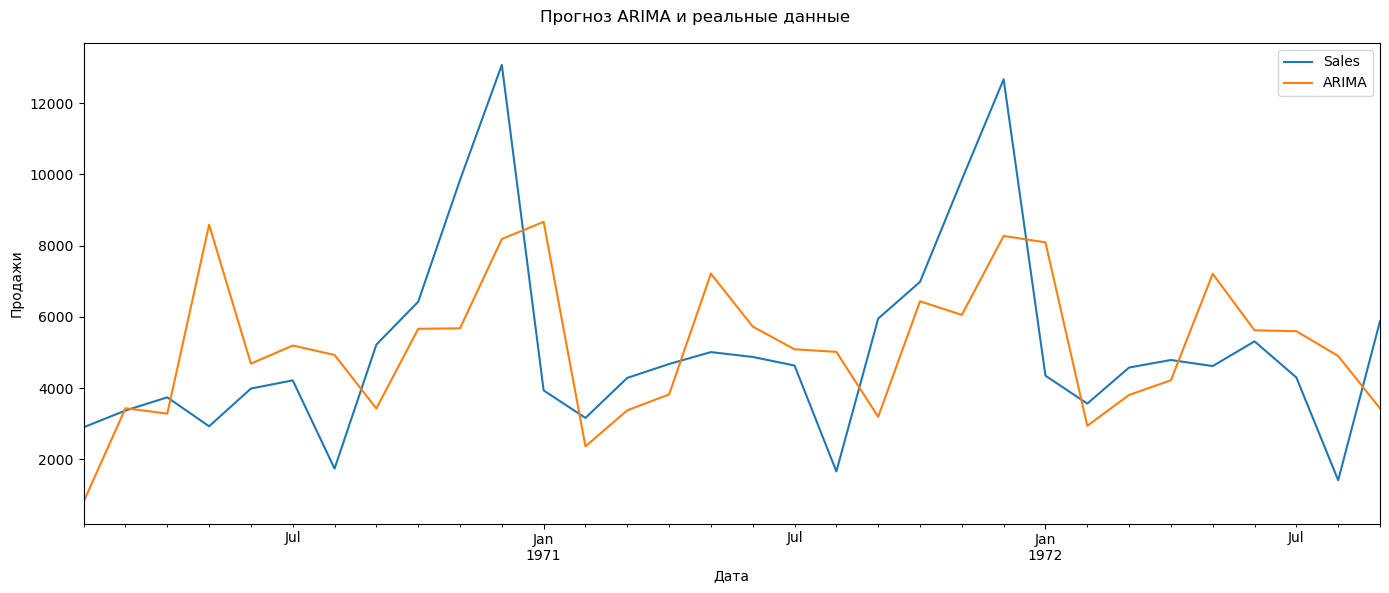

In [20]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Прогноз ARIMA и реальные данные')
ts_test[['Sales', 'ARIMA']].plot(ax=ax, legend=True)
ax.set_ylabel('Продажи')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

### График 2. Реальные данные и символьная регрессия

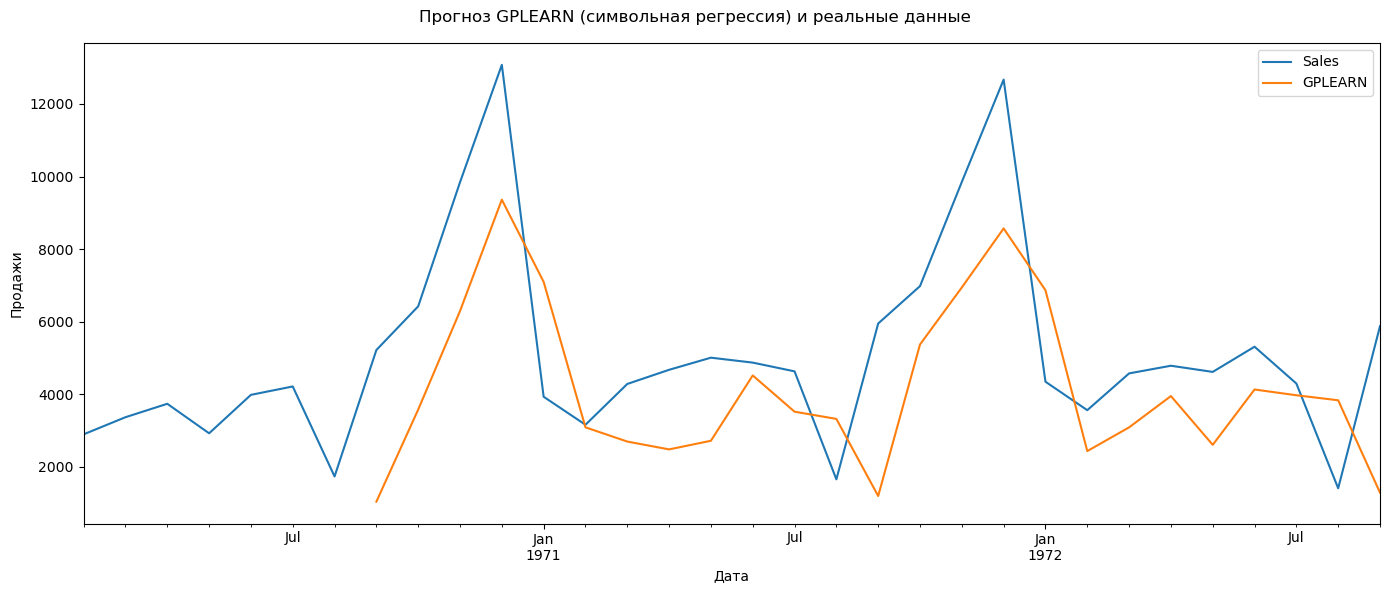

In [21]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Прогноз GPLEARN (символьная регрессия) и реальные данные')
ts_test[['Sales', 'GPLEARN']].plot(ax=ax, legend=True)
ax.set_ylabel('Продажи')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

### График 3. Реальные данные и MIA с COMBI

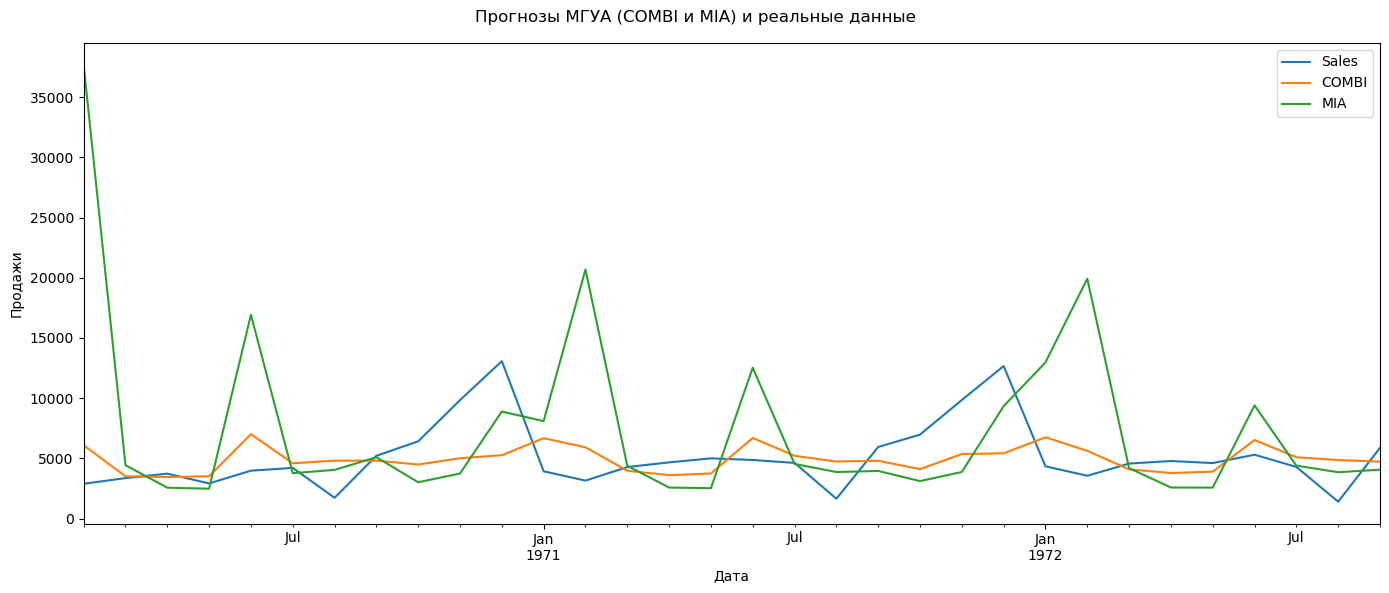

In [23]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(14, 6))
fig.suptitle('Прогнозы МГУА (COMBI и MIA) и реальные данные')
ts_test[['Sales', 'COMBI', 'MIA']].plot(ax=ax, legend=True)
ax.set_ylabel('Продажи')
ax.set_xlabel('Дата')
pyplot.tight_layout()
pyplot.show()

### 6. Оценка качества прогнозов

ARIMA:    RMSE = 2613.6287, MAE = 2070.4321
GPLEARN:  RMSE = 2622.9082, MAE = 2262.6728
COMBI:    RMSE = 2839.3897, MAE = 2135.4981
MIA:      RMSE = 8463.3294, MAE = 4888.8441
 
Сводная таблица качества прогноза
 
Метод                             RMSE          MAE
ARIMA (5,1,1)                2613.6287    2070.4321
Символьная регрессия         2622.9082    2262.6728
COMBI (лин. МГУА)            2839.3897    2135.4981
MIA (нелин. МГУА)            8463.3294    4888.8441
 
Среднее значение ряда: 4761.1524
Стд. отклонение ряда:  2541.3140


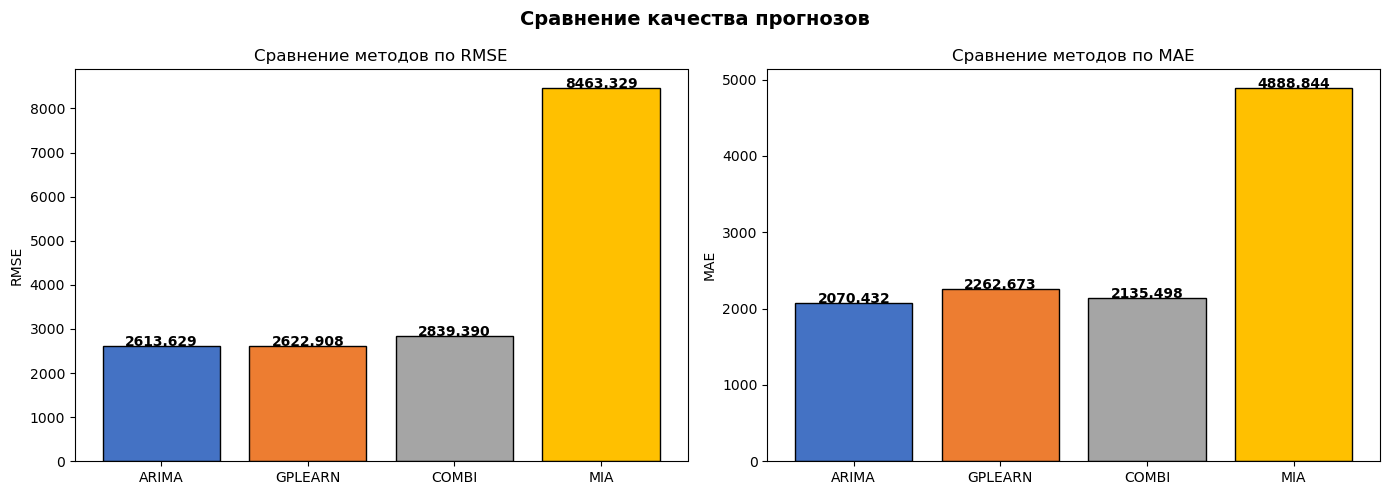

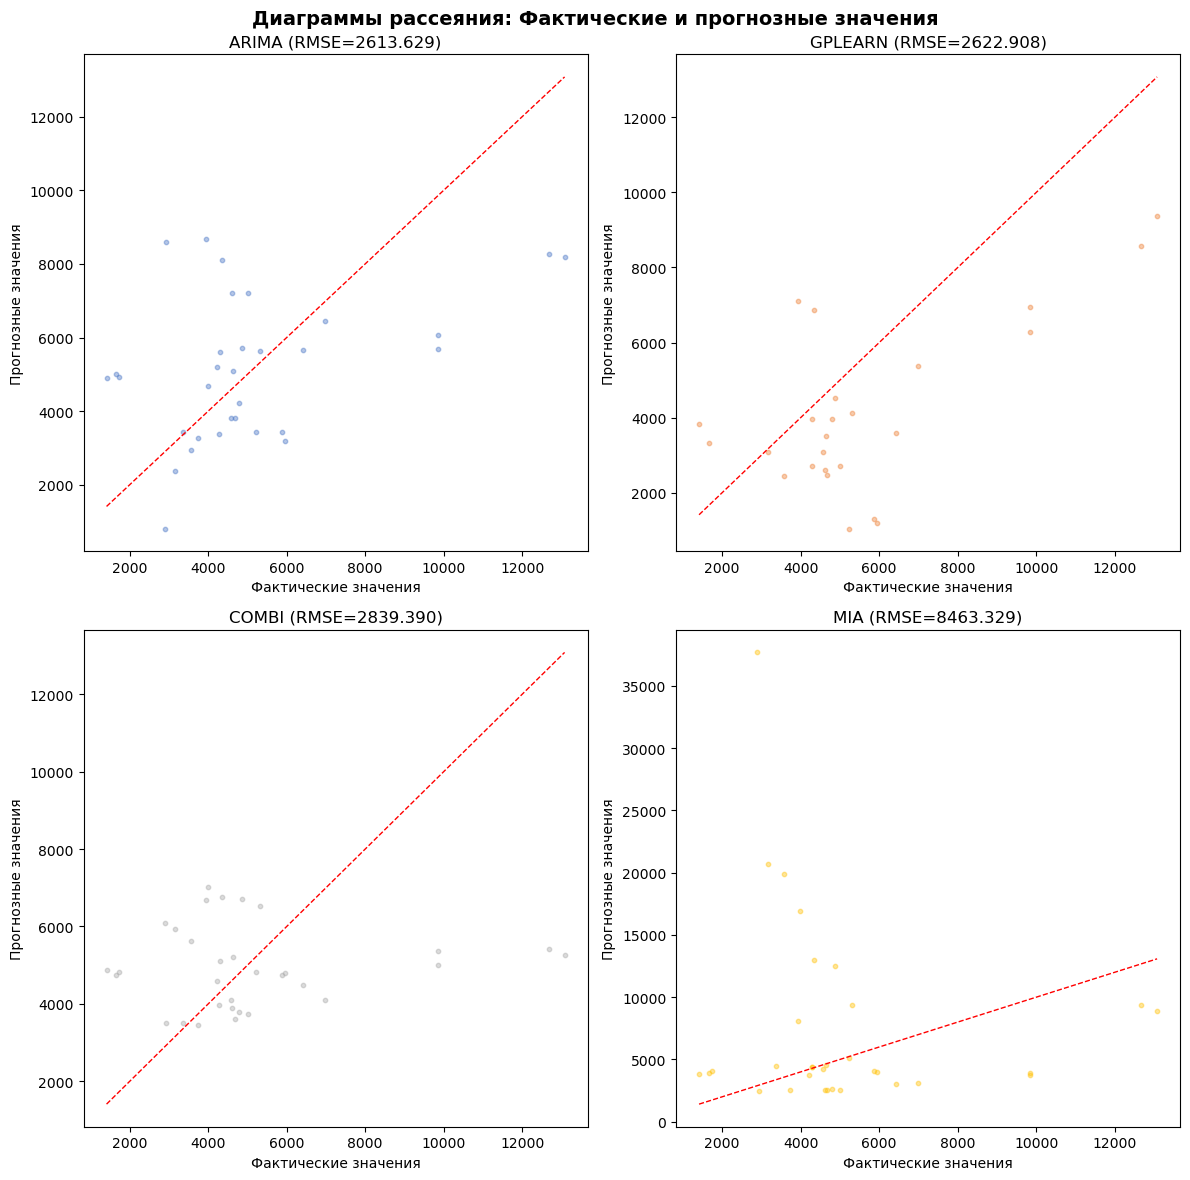

In [27]:
#расчёт метрик для каждого метода
#ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, predictions_arima))
mae_arima = mean_absolute_error(test, predictions_arima)
print(f'ARIMA:    RMSE = {rmse_arima:.4f}, MAE = {mae_arima:.4f}')

#символьная регрессия (с учётом сдвига на 7)
test_gp_aligned = test[7:]
rmse_gp = np.sqrt(mean_squared_error(test_gp_aligned, predictions_gp))
mae_gp = mean_absolute_error(test_gp_aligned, predictions_gp)
print(f'GPLEARN:  RMSE = {rmse_gp:.4f}, MAE = {mae_gp:.4f}')

#COMBI
rmse_combi = np.sqrt(mean_squared_error(test, predictions_combi))
mae_combi = mean_absolute_error(test, predictions_combi)
print(f'COMBI:    RMSE = {rmse_combi:.4f}, MAE = {mae_combi:.4f}')

#MIA
rmse_mia = np.sqrt(mean_squared_error(test, predictions_mia))
mae_mia = mean_absolute_error(test, predictions_mia)
print(f'MIA:      RMSE = {rmse_mia:.4f}, MAE = {mae_mia:.4f}')

#сводная таблица результатов
print(" ")
print('Сводная таблица качества прогноза')
print(" ")
print(f'{"Метод":<25} {"RMSE":>12} {"MAE":>12}')
print(f'{"ARIMA (5,1,1)":<25} {rmse_arima:>12.4f} {mae_arima:>12.4f}')
print(f'{"Символьная регрессия":<25} {rmse_gp:>12.4f} {mae_gp:>12.4f}')
print(f'{"COMBI (лин. МГУА)":<25} {rmse_combi:>12.4f} {mae_combi:>12.4f}')
print(f'{"MIA (нелин. МГУА)":<25} {rmse_mia:>12.4f} {mae_mia:>12.4f}')
print(" ")
print(f'Среднее значение ряда: {np.mean(Y):.4f}')
print(f'Стд. отклонение ряда:  {np.std(Y):.4f}')

#столбчатая диаграмма сравнения RMSE
methods = ['ARIMA', 'GPLEARN', 'COMBI', 'MIA']
rmse_values = [rmse_arima, rmse_gp, rmse_combi, rmse_mia]
mae_values = [mae_arima, mae_gp, mae_combi, mae_mia]
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000']
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

#RMSE
axes[0].bar(methods, rmse_values, color=colors, edgecolor='black')
axes[0].set_title('Сравнение методов по RMSE')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

#MAE
axes[1].bar(methods, mae_values, color=colors, edgecolor='black')
axes[1].set_title('Сравнение методов по MAE')
axes[1].set_ylabel('MAE')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

fig.suptitle('Сравнение качества прогнозов', fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

#рассеяние "Факт и прогноз" для каждого метода
fig, axes = pyplot.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

#ARIMA
axes[0].scatter(test, predictions_arima, alpha=0.4, s=10, color='#4472C4')
axes[0].plot([test.min(), test.max()], [test.min(), test.max()], 'r--', lw=1)
axes[0].set_xlabel('Фактические значения')
axes[0].set_ylabel('Прогнозные значения')
axes[0].set_title(f'ARIMA (RMSE={rmse_arima:.3f})')

#GPLEARN
axes[1].scatter(test_gp_aligned, predictions_gp, alpha=0.4, s=10, color='#ED7D31')
axes[1].plot([test_gp_aligned.min(), test_gp_aligned.max()], 
             [test_gp_aligned.min(), test_gp_aligned.max()], 'r--', lw=1)
axes[1].set_xlabel('Фактические значения')
axes[1].set_ylabel('Прогнозные значения')
axes[1].set_title(f'GPLEARN (RMSE={rmse_gp:.3f})')

#COMBI
axes[2].scatter(test, predictions_combi, alpha=0.4, s=10, color='#A5A5A5')
axes[2].plot([test.min(), test.max()], [test.min(), test.max()], 'r--', lw=1)
axes[2].set_xlabel('Фактические значения')
axes[2].set_ylabel('Прогнозные значения')
axes[2].set_title(f'COMBI (RMSE={rmse_combi:.3f})')

#MIA
axes[3].scatter(test, predictions_mia, alpha=0.4, s=10, color='#FFC000')
axes[3].plot([test.min(), test.max()], [test.min(), test.max()], 'r--', lw=1)
axes[3].set_xlabel('Фактические значения')
axes[3].set_ylabel('Прогнозные значения')
axes[3].set_title(f'MIA (RMSE={rmse_mia:.3f})')

fig.suptitle('Диаграммы рассеяния: Фактические и прогнозные значения', 
             fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

### Анализ точности прогнозирования продаж шампанского

#### Полученные результаты демонстрируют выраженную дифференциацию качества между методами. Прежде всего, три модели (ARIMA, GPLEARN и COMBI) обеспечили среднеквадратичную ошибку (RMSE) ниже стандартного отклонения исходного ряда (2541), что говорит о том, что они успешно выделили систематическую структуру данных, а не просто воспроизвели среднее значение.

#### ARIMA(5,1,1) показала наименьшие значения обеих метрик (RMSE = 2614, MAE = 2070). Символьная регрессия (GPLEARN) отстала по RMSE всего на 9 единиц (2623), что статистически незначимо, однако по MAE проигрыш составил уже 192 единицы (2263 против 2070). Это означает, что GPLEARN генерирует более крупные единичные ошибки, хотя в целом дисперсия ошибок сопоставима с ARIMA. Такой результат для метода, не предназначенного специально для работы с временными зависимостями, следует признать очень достойным: генетическое программирование смогло выявить нелинейные лаговые закономерности.

#### COMBI (линейная МГУА) занял промежуточную позицию: его RMSE (2839) на 8% выше, чем у ARIMA, но MAE (2135) оказалась даже лучше, чем у GPLEARN. Такое сочетание (относительно низкая MAE при повышенной RMSE) указывает на наличие умеренных, но систематических отклонений по отдельным месяцам, которые сильно увеличивают квадратичную метрику. Это может быть следствием того, что линейная комбинация лагов не всегда адекватно описывает пиковые значения (например, декабрьские всплески).

#### Нелинейная МГУА (MIA) продемонстрировала аномально высокие ошибки (RMSE = 8463, что в 3.3 раза больше σ ряда). Столь резкое ухудшение по сравнению с COMBI говорит о грубом переобучении: избыточная нелинейность (вложенные полиномы, произведения переменных) привела к тому, что модель запомнила шум на обучающей выборке и полностью потеряла обобщающую способность. Фактически MIA оказалась хуже тривиального прогноза средним (ошибка которого была бы порядка σ = 2541).

## Вывод

#### Все четыре метода, за исключением нелинейной МГУА (MIA), дали прогнозы со среднеквадратичной ошибкой (RMSE) в диапазоне 2600–2840, что значительно ниже стандартного отклонения исходного ряда (2541). Это подтверждает: модели действительно уловили закономерности, а не просто выдали среднее значение (4761). Тем не менее разброс между лучшим и худшим из «работоспособных» методов оказался скромным — около 8–9% по RMSE.